In [262]:
import numpy as np
from scipy.linalg import logm
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, floatmode='fixed')

In [263]:
def deg_to_rad(degrees):
    return degrees * (PI / 180.0)

def normalize(vector):
    # Normalization of theta (theta is a vector (1 x 7) and represents the returned value from IK())
    for i in range(len(vector)):
        if(abs(vector[i]) > 2 * PI):
            if(vector[i] < 0):
                a = -vector[i]
                a = a % (2 * PI)
                vector[i] = -a
            else: vector[i] = vector[i] % (2 * PI)

    for i in range(len(vector)):
        if((i == 3 or i == 1) and abs(vector[i]) > PI):
            a = 2 * PI - abs(vector[i])
            if(vector[i] < 0): vector[i] = a
            else: vector[i] = -a

    return vector

In [264]:
def Rx(theta_deg):
    theta_rad = deg_to_rad(theta_deg)
    
    R = np.array([
        [1.0, 0.0, 0.0],
        [0.0, np.cos(theta_rad), -np.sin(theta_rad)],
        [0.0, np.sin(theta_rad), np.cos(theta_rad)]
    ])
    
    return R 

def Ry(theta_deg):
    theta_rad = deg_to_rad(theta_deg)
    
    R = np.array([
        [np.cos(theta_rad), 0.0, np.sin(theta_rad)],
        [0.0, 1.0, 0.0],
        [-np.sin(theta_rad), 0.0, np.cos(theta_rad)]
    ])
    
    return R

def Rz(theta_deg):
    theta_rad = deg_to_rad(theta_deg)
    
    R = np.array([
        [np.cos(theta_rad), -np.sin(theta_rad), 0.0],
        [np.sin(theta_rad), np.cos(theta_rad), 0.0],
        [0.0, 0.0, 1.0]
    ])
    
    return R

def T(R, p):
    transf_matrix = np.eye(4)
    transf_matrix[:3, :3] = R
    transf_matrix[:3, 3] = p
    
    return transf_matrix

In [265]:
def hat(vector):
    if(vector.shape[0] == 3):
        vector_hat = np.array([
            [0, -vector[2], vector[1]],
            [vector[2], 0, -vector[0]],
            [-vector[1], vector[0], 0]
        ]) 
    else:
        w = vector[:3]
        v = vector[3:]
        
        # skew symmetric of w
        w_hat = np.array([
            [0, -w[2], w[1]],
            [w[2], 0, -w[0]],
            [-w[1], w[0], 0]
        ])
        
        # skew symmetric matrix
        vector_hat = np.zeros((4, 4))
        vector_hat[:3, :3] = w_hat
        vector_hat[:3, 3] = v

    return vector_hat

def unhat(vector_hat):
    if(vector_hat.shape[0] == 3):
        vector_unhat = np.zeros((3, 1))

        vector_unhat[0] = vector_hat[2, 1]
        vector_unhat[1] = vector_hat[0, 2]
        vector_unhat[2] = vector_hat[1, 0]
    else:
        vector_unhat = np.zeros((6, 1))

        vector_unhat[0] = vector_hat[2, 1]
        vector_unhat[1] = vector_hat[0, 2]
        vector_unhat[2] = vector_hat[1, 0]
        vector_unhat[3] = vector_hat[0, 3]
        vector_unhat[4] = vector_hat[1, 3]
        vector_unhat[5] = vector_hat[2, 3]

    return vector_unhat 

def Ad(T):
    R = T[0:3, 0:3]
    p = T[0:3, 3]

    p_hat = hat(p)
    
    adj_T = np.zeros((6, 6))
    adj_T[0:3, 0:3] = R
    adj_T[3:, 0:3] = p_hat @ R
    adj_T[3:, 3:] = R

    return adj_T

def pseudo_inverse(J):
    J_T = J.T
    pseudo_inv_J = J_T @ np.linalg.inv(J @ J_T) # n (= 7) > m (= 6)

    return pseudo_inv_J

In [267]:
def exp_rotation(theta): # lecture 3, page 14
    theta = theta.reshape(3, 1) # θ (bold)
    phi = np.linalg.norm(theta) # θ
    
    R = np.eye(3)

    if not (phi < 1e-12):
        r = theta / phi
        R = np.eye(3) * np.cos(phi) + (1. - np.cos(phi)) * r @ r.T + np.sin(phi) * hat(r.reshape(3))

    return R

def exp_pose(tau):       # lecture 4, page 16
    theta = np.linalg.norm(tau[:3, :])
    
    R = np.eye(3)
    A = tau[3:, :]
        
    if not (theta < 1e-12):
        R = exp_rotation(tau[:3, :])
        r = tau[:3, :] / theta
        rho = tau[3:, :] / theta
        r_hat = hat(r.reshape(3))
        A = (np.eye(3) * theta + (1. - np.cos(theta)) * r_hat + (theta - np.sin(theta)) * (r_hat @ r_hat)) @ rho    
    
    T = np.zeros((4, 4))
    T[0:3, 0:3] = R
    T[0:3, 3:] = A
    T[3, :] = [0.0, 0.0, 0.0, 1.0]
    
    return T

def log_rotation(R):     # lecture 3, page 14
    phi = np.arccos(max(-1., min(1., (np.trace(R) - 1.) / 2.)))
    
    theta = np.zeros((3, 1))
    
    if not (((phi < 1e-12) or (phi >= PI))):
        r_hat = (1. / (2. * np.sin(phi))) * (R - R.T)
        theta = unhat(phi * r_hat)
    
    return theta

def log_pose(T):         # lecture 4, page 17
    R = T[:3, :3]
    p = T[:3, 3:]
    
    theta = log_rotation(R)     # θ bold
    phi = np.linalg.norm(theta) # θ
    tau = np.zeros((6, 1))
    tau[3:, :] = p
    
    if not (phi < 1e-12):
        r_hat = hat(theta.reshape(3)) / phi
        rho = ((1. / phi) * np.eye(3) - 0.5 * r_hat + (1. / phi - 0.5 / np.tan(phi / 2.)) * (r_hat @ r_hat)) @ p * phi

        tau[0:3, :] = theta
        tau[3:, :] = rho

    return tau

In [268]:
# Forward Kinematics
def FK(S, theta, M):
    Tw_ee = np.eye(4)

    for i in range(len(theta)):        
        Tw_ee = Tw_ee @ exp_pose((S[i] * theta[i]).reshape(6, 1))

    Tw_ee = Tw_ee @ M

    return Tw_ee

# Inverse Kinematics
def IK(goal_pos, initial_theta, M):
    theta_history = []
    norm_history = []

    theta = initial_theta

    Vw = np.zeros((6, 1)) # Vw (Space Twist)
    delta_theta = np.zeros((7, 1))

    iterations = 0
    while(np.linalg.norm(Vw[:3, :]) >= 1e-3 or np.linalg.norm(Vw) == 0):
        iterations += 1
        
        # Jacobian
        Jw_T = []  # Transpose Space Jacobian (Jw_T) ---> dimensions: (7 x 6)
        exp_p = [] # Exponential Pose

        for i in range(len(theta)):
            exp_p.append(exp_pose((S[i] * theta[i]).reshape(6, 1)))

        Jw_T.append(S[0, :])
        Jw_T.append(Ad(exp_p[0]) @ (S[1, :]))

        x = exp_p[0]
        for i in range(1, len(exp_p)-1):
            y = exp_p[i]
            x = x @ y
            z = Ad(x) @ S[i+1, :]

            Jw_T.append(z)

        Jw_T = np.array(Jw_T) # dimensions: (7 x 6)
        Jw = Jw_T.T.copy()    # dimensions: (6 x 7)
        Jw_T = list(Jw_T)
        Jw_pseudo_inv = pseudo_inverse(Jw)
        
        # Neuton-Raphson
        current_pos = np.linalg.inv(FK(S, theta, M))
        Vw = log_pose(goal_pos @ current_pos)

        delta_theta = Jw_pseudo_inv @ Vw
        theta += delta_theta.T.flatten()

        theta_history.append(theta.copy())
        norm_history.append(np.linalg.norm(Vw))
    
    # Plots
    theta_history = np.array(theta_history)    # red
    theta_history = theta_history * (180 / PI) # degrees
    norm_history = np.array(norm_history)

    fig1 = plt.figure(figsize = (16, 9))
    for i in range(7):
        plt.subplot(3, 3, i+1)
        plt.plot(theta_history[:, i])
        plt.title(f'Joint {i+1} Angle Evolution')
        plt.xlabel('Iterations')
        plt.ylabel('Theta (degrees)')
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    fig2 = plt.figure(figsize = (16, 9))
    plt.plot(norm_history)
    plt.title(f'Norm history')
    plt.xlabel('Iterations')
    plt.ylabel('||Vw||')
    plt.grid(True)
    plt.show()
    
    print("> Iterations = ", iterations)

    return theta

In [269]:
# Transformation Matrices
PI = np.pi

Rw = np.eye(3)
Rw_base = Rw
Rw_xF = np.dot(Rw_base, np.dot(np.dot(Rx(180.0), Ry(0.0)), Rz(0.0)))

# > Transformation of the end-effector frame when all joints are in the home configuration (M)
Rw_ee = np.dot(Rw_xF, np.dot(np.dot(Rx(0.0), Ry(0.0)), Rz(-45.0)))
pw_ee = [0.088, 0.0, 0.926]
M = T(Rw_ee, pw_ee)

# > Desired pose of the end-effector such that is able to grasp the cylinder (wrt world frame)
Rw_ee_des1 = np.dot(np.dot(np.dot(Rx(0.0), Ry(0.0)), Rz(-45.0)), Rw_ee)
pw_ee_des1 = [0.695, 0.095, 0.02]
Tw_ee_des1 = T(Rw_ee_des1, pw_ee_des1)

# > Desired pose of the end-effector such that the cylinder is positioned in the “placing” position above the hole
Rw_ee_des2 = np.dot(np.dot(np.dot(Rx(0.0), Ry(-90.0)), Rz(-45.0)), Rw_ee)
pw_ee_des2 = [0.5, 0.5, 0.325]
Tw_ee_des2 = T(Rw_ee_des2, pw_ee_des2)
    
initial_theta = [0.0, 0.0, 0.0, -0.01, 0.0, -0.01, -0.01] # home configuration

In [270]:
# Screw Axis
r = np.array([
    [0.0, 0.0, 1.0],  #1 OK
    [0.0, 1.0, 0.0],  #2 OK
    [0.0, 0.0, 1.0],  #3 OK
    [0.0, -1.0, 0.0], #4 OK
    [0.0, 0.0, 1.0],  #5 OK
    [0.0, -1.0, 0.0], #6 OK
    [0.0, 0.0, -1.0]  #7 OK
])

q = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.333],
    [0.0, 0.0, 0.0],
    [0.088, 0.0, 0.649],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 1.033],
    [0.088, 0.0, 0.0]
])

S = np.zeros((7, 6))

for i in range(S.shape[0]):
    r_i = r[i]
    q_i = q[i]
    p_i = -np.cross(r_i, q_i)
    S[i, :3] = r_i
    S[i, 3:] = p_i

In [271]:
# Coefficients for Trajectory with Cubic Splines
Ttotal = 1.      # total time
Ts = M           # starting transformation matrix
Tg = Tw_ee_des1  # desired transformation matrix

tau_s = log_pose(Ts) # τs
tau_g = log_pose(Tg) # τg

Vs = np.array([[0.], [0.], [0.], [0.], [0.], [0.]]).reshape(6, 1) # starting velocities
Vg = np.array([[0.], [0.], [0.], [0.], [0.], [0.]]).reshape(6, 1) # desired velocities

c0 = tau_s.reshape(6)
c1 = Vs.reshape(6)
c2 = (3 * tau_g / (Ttotal**2) - 3 * tau_s / (Ttotal**2) - 2 * Vs / Ttotal - Vg / Ttotal).reshape(6)
c3 = (-2 * tau_g / (Ttotal**3) + 2 * tau_s / (Ttotal**3) + Vs / (Ttotal**2) + Vg / (Ttotal**2)).reshape(6)

In [272]:
# Cubic Splines
def T_cubic_splines(t):
    tau = unhat(hat(c3) * (t**3) + hat(c2) * (t**2) + hat(c1) * t + hat(c0))
    T = exp_pose(tau)
    
    return T

def T_dot_cubic_splines(t):
    tau = unhat((3 * hat(c3) * (t**2) + 2 * hat(c2) * t + hat(c1)) @ T_cubic_splines(t)) 
    T_dot = exp_pose(tau)

    return T_dot

[array([[1.0000, 0.0000, 0.0000, 0.0880],
       [0.0000, 1.0000, 0.0000, 0.0000],
       [0.0000, 0.0000, 1.0000, 0.9260],
       [0.0000, 0.0000, 0.0000, 1.0000]]), array([[1.0000, 0.0000, 0.0000, 0.1050],
       [0.0000, 1.0000, 0.0000, 0.0027],
       [0.0000, 0.0000, 1.0000, 0.9006],
       [0.0000, 0.0000, 0.0000, 1.0000]]), array([[1.0000, 0.0000, 0.0000, 0.1511],
       [0.0000, 1.0000, 0.0000, 0.0099],
       [0.0000, 0.0000, 1.0000, 0.8318],
       [0.0000, 0.0000, 0.0000, 1.0000]]), array([[1.0000, 0.0000, 0.0000, 0.2191],
       [0.0000, 1.0000, 0.0000, 0.0205],
       [0.0000, 0.0000, 1.0000, 0.7303],
       [0.0000, 0.0000, 0.0000, 1.0000]]), array([[1.0000, 0.0000, 0.0000, 0.3017],
       [0.0000, 1.0000, 0.0000, 0.0334],
       [0.0000, 0.0000, 1.0000, 0.6071],
       [0.0000, 0.0000, 0.0000, 1.0000]]), array([[1.0000, 0.0000, 0.0000, 0.3915],
       [0.0000, 1.0000, 0.0000, 0.0475],
       [0.0000, 0.0000, 1.0000, 0.4730],
       [0.0000, 0.0000, 0.0000, 1.0000]]), arr

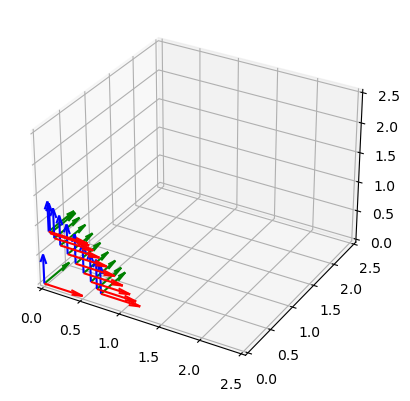

In [273]:
# Trajectory with Cubic Splines
times = np.arange(0., Ttotal, 0.1)
traj = []

for t in times:
    traj.append(T_cubic_splines(t))

print(traj)

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

# World frame
origin = [0., 0., 0.]
x_axis = [1., 0., 0.]
y_axis = [0., 1., 0.]
z_axis = [0., 0., 1.]

ax.quiver(*origin, *x_axis, color='r', length=0.5, normalize=True)
ax.quiver(*origin, *y_axis, color='g', length=0.5, normalize=True)
ax.quiver(*origin, *z_axis, color='b', length=0.5, normalize=True)

# Trajectory frames
for i in range(len(traj)):
    origin = traj[i][:3, 3]
    x_axis = traj[i][:3, 0]
    y_axis = traj[i][:3, 1]
    z_axis = traj[i][:3, 2]

    x_axis = x_axis / np.linalg.norm(x_axis)
    y_axis = y_axis / np.linalg.norm(y_axis)
    z_axis = z_axis / np.linalg.norm(z_axis)

    ax.quiver(*origin, *x_axis, color='r', length=0.5, normalize=True)
    ax.quiver(*origin, *y_axis, color='g', length=0.5, normalize=True)
    ax.quiver(*origin, *z_axis, color='b', length=0.5, normalize=True)

ax.set_xlim([0., 2.5])
ax.set_ylim([0., 2.5])
ax.set_zlim([0., 2.5])

plt.show()